In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# These imports assume your local modules are set up as below.
# Adjust them to match your actual file structure if needed.
from multi_llm_debate.analysis.correct_rate_by_round import (
    calculate_correct_rate_by_round,
    calculate_majority_vote_correct_rate
)
from multi_llm_debate.analysis.calculate_task_accuracy import analyze_task_accuracy


# ==========================
# 1. CONFIGURATION
# ==========================
DATA_PATH = Path("../output/bool_q/processed_data.csv")
MODEL_DIR_PATH = Path("../data/bool_q")

# Accuracy cutoffs for easy/medium/hard
EASY_THRESHOLD = 0.7
MEDIUM_THRESHOLD = 0.1

# We only want directories whose parentheses-based digit sum == 6
TARGET_MODEL_COUNT = 6

# Maximum round number for your correct_rate_by_round function
MAX_ROUND_NUMBER = 10


# ==========================
# 2. HELPER FUNCTIONS
# ==========================
def get_total_model_count(dir_name: str) -> int:
    """
    Parses folder name (e.g., 'llama3(3)+mistral(3)') 
    to sum up the numeric values found in parentheses.
    """
    # Find all digits inside parentheses: e.g. "(3)", "(6)"
    matches = re.findall(r"\((\d+)\)", dir_name)
    # Convert each match to an integer and sum
    return sum(int(m) for m in matches)


def create_plot(
    easy_rates, medium_rates, hard_rates, overall_rates,
    easy_mv_rate, medium_mv_rate, hard_mv_rate, overall_mv_rate,
    model_name
):
    """
    Plots round-by-round correct rates for easy, medium, hard, and overall tasks,
    along with corresponding majority-vote horizontal lines.
    """
    # Define the colors for the plot
    colors = {
        "easy": 'g',     # Green for Easy
        "medium": 'y',   # Yellow for Medium
        "hard": 'r',     # Red for Hard
        "overall": 'b',  # Blue for Overall
    }
    
    # Determine how many rounds we have data for
    max_rounds = max(
        len(easy_rates),
        len(medium_rates),
        len(hard_rates),
        len(overall_rates)
    )
    rounds = range(max_rounds)

    plt.figure(figsize=(10, 6))

    # Plot lines only if there's data
    if len(easy_rates) > 0:
        plt.plot(rounds, easy_rates, f'{colors["easy"]}-o', label='Easy Tasks', linewidth=2)
    if len(medium_rates) > 0:
        plt.plot(rounds, medium_rates, f'{colors["medium"]}-s', label='Medium Tasks', linewidth=2)
    if len(hard_rates) > 0:
        plt.plot(rounds, hard_rates, f'{colors["hard"]}-d', label='Hard Tasks', linewidth=2)
    if len(overall_rates) > 0:
        plt.plot(rounds, overall_rates, f'{colors["overall"]}-*', label='Overall', linewidth=2)

    # Horizontal lines for majority vote rates
    plt.axhline(y=easy_mv_rate, color=colors["easy"], linestyle='--', label='Easy Majority Vote')
    plt.axhline(y=medium_mv_rate, color=colors["medium"], linestyle='--', label='Medium Majority Vote')
    plt.axhline(y=hard_mv_rate, color=colors["hard"], linestyle='--', label='Hard Majority Vote')
    plt.axhline(y=overall_mv_rate, color=colors["overall"], linestyle='--', label='Overall Majority Vote')

    # Construct the chart title
    plt.title(
        f'Correct Rate by Round: {model_name}\n'
        f'(Easy >= {EASY_THRESHOLD}, '
        f'{MEDIUM_THRESHOLD} <= Medium < {EASY_THRESHOLD}, '
        f'Hard < {MEDIUM_THRESHOLD})',
        pad=15
    )
    plt.xlabel('Round Number')
    plt.ylabel('Correct Rate')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Set y-axis limits and ticks
    plt.ylim(0, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(rounds)

    plt.tight_layout()
    plt.show()


def process_model(model_dir: Path):
    """
    Performs the entire pipeline for a given model directory:
    1) Analyze accuracy,
    2) Split tasks by easy/medium/hard using "accuracy" column,
    3) Compute correct rates by round,
    4) Compute majority-vote correctness,
    5) Generate the plot.
    """
    model_name = model_dir.name  # The directory name, e.g. "llama3(3)+mistral(3)"
    print(f"\nProcessing model: {model_name}")

    # -------------------------------------------------------------
    # 1. (Optional) Analyze and update the dataframe with accuracy 
    #    if your pipeline needs it. Otherwise, skip this step.
    # -------------------------------------------------------------
    result_df = analyze_task_accuracy(
        model_dir=model_dir,
        dataframe=df,  # Global DataFrame loaded below
    )

    # -------------------------------------------------------------
    # 2. Categorize tasks by "accuracy": easy / medium / hard
    # -------------------------------------------------------------
    easy_df = result_df[result_df["accuracy"] >= EASY_THRESHOLD]
    medium_df = result_df[
        (result_df["accuracy"] < EASY_THRESHOLD) & (result_df["accuracy"] >= MEDIUM_THRESHOLD)
    ]
    hard_df = result_df[result_df["accuracy"] < MEDIUM_THRESHOLD]

    # -------------------------------------------------------------
    # 3. Calculate correct rates by round
    # -------------------------------------------------------------
    easy_cr = calculate_correct_rate_by_round(easy_df, model_dir, max_round_number=MAX_ROUND_NUMBER)
    medium_cr = calculate_correct_rate_by_round(medium_df, model_dir, max_round_number=MAX_ROUND_NUMBER)
    hard_cr = calculate_correct_rate_by_round(hard_df, model_dir, max_round_number=MAX_ROUND_NUMBER)
    overall_cr = calculate_correct_rate_by_round(result_df, model_dir, max_round_number=MAX_ROUND_NUMBER)

    # Extract the row where 'metric' == 'absolute' and then pull columns from round_1 .. round_N
    def get_rates(df_cr: pd.DataFrame):
        if df_cr.empty:
            return []
        row_abs = df_cr[df_cr['metric'] == 'absolute']
        if row_abs.empty:
            return []
        return row_abs.iloc[0, 2:].values  # skipping columns "metric" and "model_dir"

    easy_rates = get_rates(easy_cr)
    medium_rates = get_rates(medium_cr)
    hard_rates = get_rates(hard_cr)
    overall_rates = get_rates(overall_cr)

    # -------------------------------------------------------------
    # 4. Calculate majority-vote correctness
    # -------------------------------------------------------------
    easy_mv_rate = ( 
        calculate_majority_vote_correct_rate(easy_df, model_dir) 
        if not easy_df.empty else 0.0
    )
    medium_mv_rate = (
        calculate_majority_vote_correct_rate(medium_df, model_dir)
        if not medium_df.empty else 0.0
    )
    hard_mv_rate = (
        calculate_majority_vote_correct_rate(hard_df, model_dir)
        if not hard_df.empty else 0.0
    )
    overall_mv_rate = calculate_majority_vote_correct_rate(result_df, model_dir)

    # -------------------------------------------------------------
    # 5. Create the plot
    # -------------------------------------------------------------
    create_plot(
        easy_rates, medium_rates, hard_rates, overall_rates,
        easy_mv_rate, medium_mv_rate, hard_mv_rate, overall_mv_rate,
        model_name
    )


# ==========================
# 3. MAIN SCRIPT
# ==========================
if __name__ == "__main__":
    # Load your main data
    df = pd.read_csv(DATA_PATH)

    # Get all model directories
    all_model_dirs = list(MODEL_DIR_PATH.glob('*'))

    # Filter directories by total model count == TARGET_MODEL_COUNT
    filtered_model_dirs = [
        d for d in all_model_dirs
        if get_total_model_count(d.name) == TARGET_MODEL_COUNT
    ]

    print("Filtered directories (sum of parentheses == 6):")
    for d in filtered_model_dirs:
        print("  -", d.name)

    # Now, process each filtered directory
    for model_dir in filtered_model_dirs:
        process_model(model_dir)


Filtered directories (sum of parentheses == 6):
  - llama2(3)+llama3(3)
  - llama3(3)+mistral(3)
  - llama2(3)+mistral(3)
  - llama3(6)
  - llama2(6)

Processing model: llama2(3)+llama3(3)
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/4780: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/7627: Answer not recognized


Filtered directories (sum of parentheses == 6):
  - llama2(3)+llama3(3)
  - llama3(3)+mistral(3)
  - llama2(3)+mistral(3)
  - llama3(6)
  - llama2(6)

Processing model: llama2(3)+llama3(3)
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/4780: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/7627: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+llama3(3)/767: Answer not recognized


Processing llama2(3)+llama3(3): 100%|██████████| 2000/2000 [00:00<00:00, 5031.69it/s]
/var/folders/_0/9lcpl6ds451bxrqdll83hcbc0000gn/T/ipykernel_53137/4241540351.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(sorted_items))


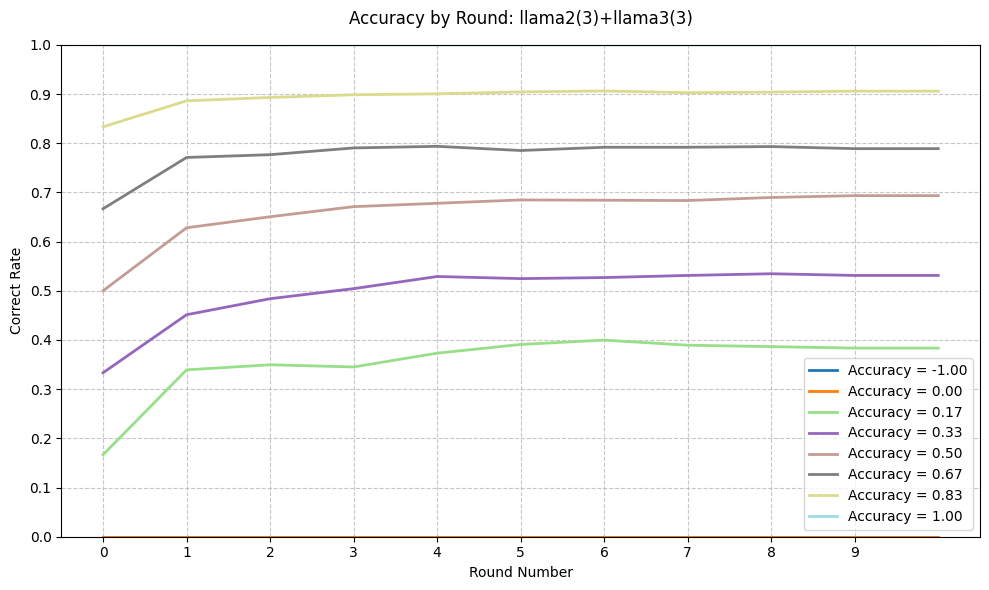


Processing model: llama3(3)+mistral(3)
Error processing task directory ../data/bool_q/llama3(3)+mistral(3)/3820: Answer not recognized


Processing llama3(3)+mistral(3): 100%|██████████| 2000/2000 [00:00<00:00, 4966.93it/s]
/var/folders/_0/9lcpl6ds451bxrqdll83hcbc0000gn/T/ipykernel_53137/4241540351.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(sorted_items))


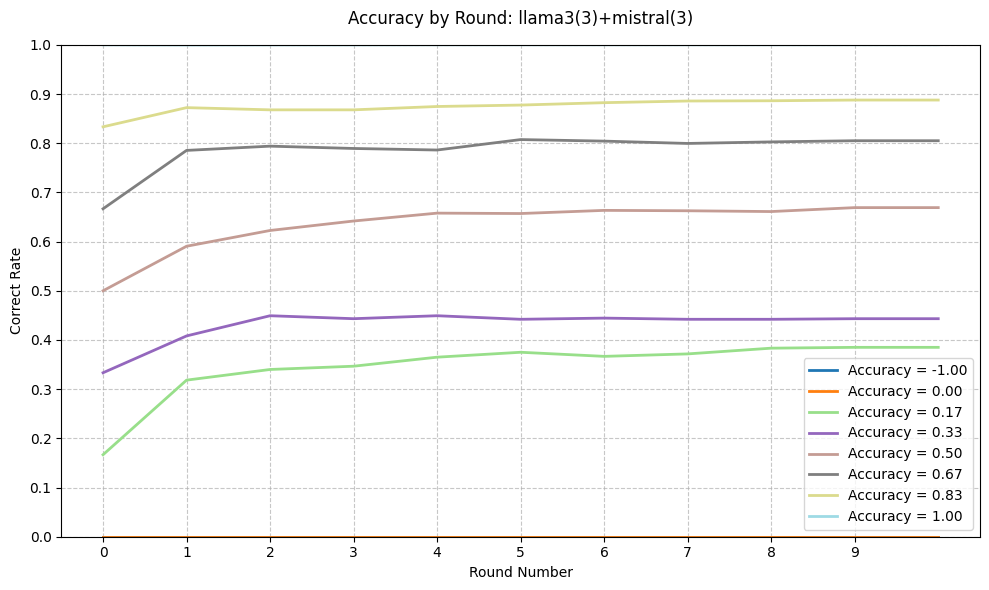


Processing model: llama2(3)+mistral(3)
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/5838: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/2877: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/4013: Answer not recognized
Error processing task directory ../data/bool_q/llama2(3)+mistral(3)/7745: Answer not recognized


Processing llama2(3)+mistral(3): 100%|██████████| 2000/2000 [00:00<00:00, 8412.38it/s]
/var/folders/_0/9lcpl6ds451bxrqdll83hcbc0000gn/T/ipykernel_53137/4241540351.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(sorted_items))


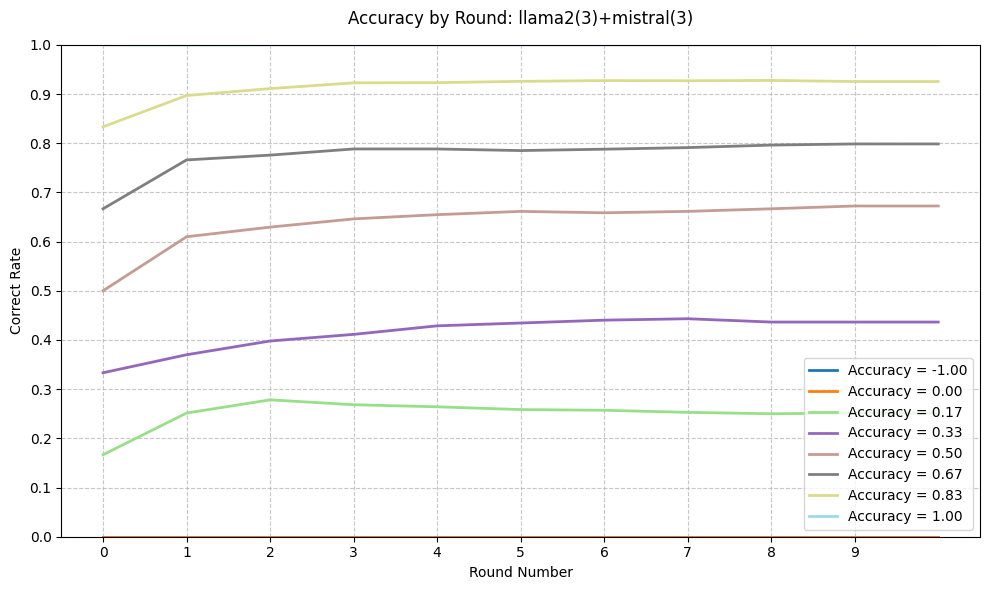


Processing model: llama3(6)
Error processing task directory ../data/bool_q/llama3(6)/4044: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/8754: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/1938: Answer not recognized
Error processing task directory ../data/bool_q/llama3(6)/320: Answer not recognized


Processing llama3(6): 100%|██████████| 2000/2000 [00:00<00:00, 6149.95it/s]
/var/folders/_0/9lcpl6ds451bxrqdll83hcbc0000gn/T/ipykernel_53137/4241540351.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(sorted_items))


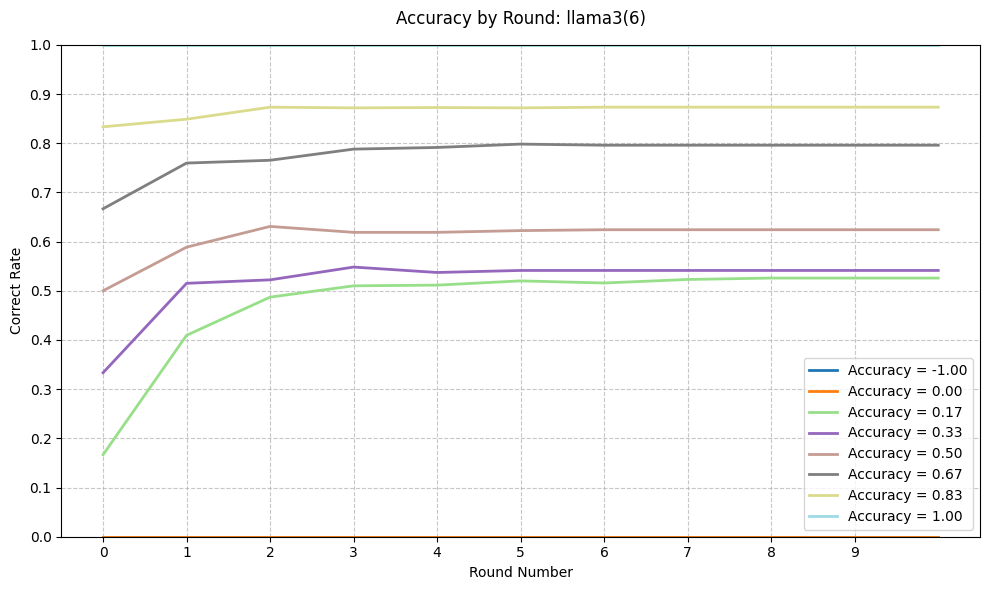


Processing model: llama2(6)
Error processing task directory ../data/bool_q/llama2(6)/7157: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/872: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/11: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/767: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/2877: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/5820: Answer not recognized
Error processing task directory ../data/bool_q/llama2(6)/7745: Answer not recognized


Processing llama2(6): 100%|██████████| 2000/2000 [00:00<00:00, 5221.73it/s]
/var/folders/_0/9lcpl6ds451bxrqdll83hcbc0000gn/T/ipykernel_53137/4241540351.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(sorted_items))


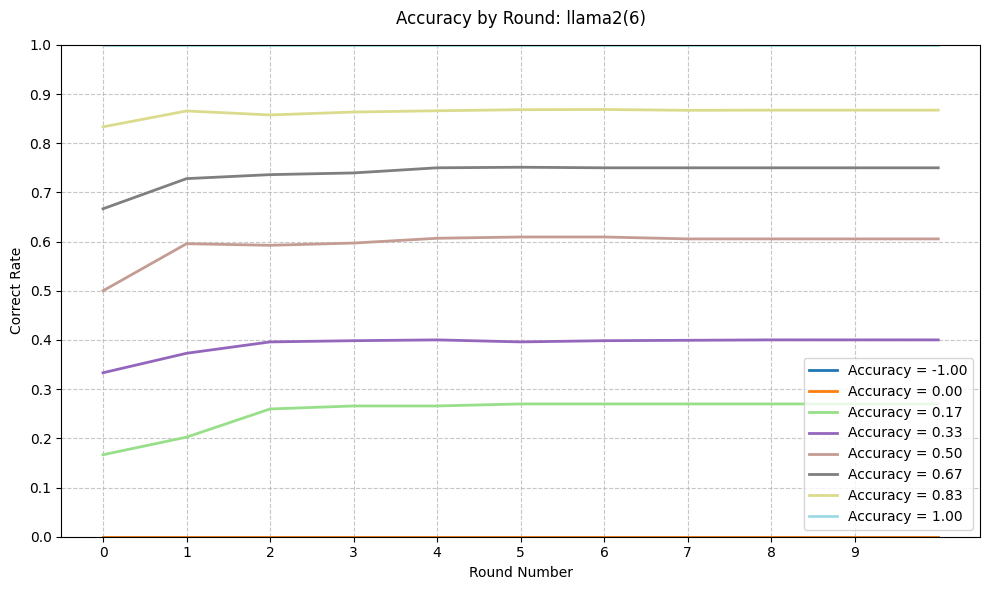

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# These imports assume your local modules are set up as below.
# Adjust them to match your actual file structure if needed.
from multi_llm_debate.analysis.correct_rate_by_round import (
    calculate_correct_rate_by_round,
    calculate_majority_vote_correct_rate
)
from multi_llm_debate.analysis.calculate_task_accuracy import analyze_task_accuracy


# ==========================
# 1. CONFIGURATION
# ==========================
DATA_PATH = Path("../output/bool_q/processed_data.csv")
MODEL_DIR_PATH = Path("../data/bool_q")

# We only want directories whose parentheses-based digit sum == 6
TARGET_MODEL_COUNT = 6

# Maximum round number for your correct_rate_by_round function
MAX_ROUND_NUMBER = 10


# ==========================
# 2. HELPER FUNCTIONS
# ==========================
def get_total_model_count(dir_name: str) -> int:
    """
    Parses folder name (e.g., 'llama3(3)+mistral(3)') 
    to sum up the numeric values found in parentheses.
    """
    matches = re.findall(r"\((\d+)\)", dir_name)
    return sum(int(m) for m in matches)


def create_plot(accuracies_by_round, model_name):
    """
    Plots a line for each unique accuracy value from the correct_rate_by_round results,
    with the legend sorted by ascending accuracy values.
    """
    # Sort the dictionary items by the accuracy value (the dictionary key)
    sorted_items = sorted(accuracies_by_round.items(), key=lambda x: x[0])
    
    # Use a color map, sized to the number of unique accuracy lines
    colors = plt.cm.get_cmap('tab20', len(sorted_items))

    plt.figure(figsize=(10, 6))

    # Plot a line for each unique accuracy value, in descending order
    for idx, (accuracy, accuracy_values) in enumerate(sorted_items[::-1]):
        rounds = range(len(accuracy_values))
        plt.plot(
            rounds,
            accuracy_values,
            label=f'Accuracy = {accuracy:.2f}',
            color=colors(idx),
            linewidth=2,
        )

    # Title and labels
    plt.title(f'Accuracy by Round: {model_name}', pad=15)
    plt.xlabel('Round Number')
    plt.ylabel('Correct Rate')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Set y-axis limits and ticks
    plt.ylim(0, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(range(MAX_ROUND_NUMBER))

    plt.tight_layout()
    plt.show()


def process_model(model_dir: Path):
    """
    1) Analyze accuracy,
    2) Calculate correct rates for each unique accuracy value,
    3) Plot the results.
    """
    model_name = model_dir.name
    print(f"\nProcessing model: {model_name}")

    # 1) Analyze accuracy
    result_df = analyze_task_accuracy(
        model_dir=model_dir,
        dataframe=df  # Global DataFrame loaded from main
    )

    # 2) Get all unique accuracy values from the result dataframe
    unique_accuracies = result_df['accuracy'].unique()

    # 3) Create a dictionary to store the accuracy values by round
    accuracies_by_round = {accuracy: [] for accuracy in unique_accuracies}

    # 4) For each unique accuracy value, calculate the fraction of tasks per round
    for accuracy in unique_accuracies:
        # Filter tasks by accuracy
        filtered_df = result_df[result_df['accuracy'] == accuracy]
        
        # Calculate correct rates for this accuracy using calculate_correct_rate_by_round
        cr_filtered_df = calculate_correct_rate_by_round(filtered_df, model_dir, max_round_number=MAX_ROUND_NUMBER)
        
        # Extract the correct rates for this accuracy value
        accuracies_by_round[accuracy] = cr_filtered_df[
            cr_filtered_df['metric'] == 'absolute'
        ].iloc[0, 2:].values

    # 5) Create the plot
    create_plot(accuracies_by_round, model_name)


# ==========================
# 3. MAIN SCRIPT
# ==========================
if __name__ == "__main__":
    # Load the main data
    df = pd.read_csv(DATA_PATH)

    # Get all model directories
    all_model_dirs = list(MODEL_DIR_PATH.glob('*'))

    # Filter directories by total model count == TARGET_MODEL_COUNT
    filtered_model_dirs = [
        d for d in all_model_dirs
        if get_total_model_count(d.name) == TARGET_MODEL_COUNT
    ]

    print("Filtered directories (sum of parentheses == 6):")
    for d in filtered_model_dirs:
        print("  -", d.name)

    # Process each filtered directory
    for model_dir in filtered_model_dirs:
        process_model(model_dir)
